## 1. Introducción

Este trabajo tiene como objetivo realizar un análisis exploratorio y visual del mercado de relojes de lujo utilizando Python. El dataset incluye información de marcas, materiales, dimensiones, complicaciones, resistencia al agua y precios de diferentes modelos.

Se aplicarán técnicas de limpieza, análisis estadístico, detección de outliers, agrupación y visualización con `pandas`, `numpy`, `matplotlib` y `seaborn`.

- Link al dataset: https://www.kaggle.com/datasets/rkiattisak/luxury-watches-price-dataset

### 1.1 Motivación

El mercado de los relojes de lujo representa una industria compleja donde confluyen diseño, ingeniería, marca, materiales y percepción de valor. Comprender cómo varían las características técnicas (materiales, movimiento, dimensiones...) en relación con el precio es clave tanto para el análisis de producto como para estrategias de posicionamiento.

Este trabajo parte del interés por explorar un conjunto de datos real de modelos de relojes de lujo, con el fin de identificar patrones, relaciones y comportamientos significativos. Utilizando herramientas de análisis y visualización de datos, se pretende aportar una perspectiva técnica y visual sobre los factores que influyen en el valor de estos productos.

Además, este estudio sirve como ejercicio práctico para aplicar conocimientos adquiridos en el curso sobre manejo y análisis de datos con Python, utilizando librerías como `pandas`, `seaborn`, `matplotlib` y `numpy`.

### 1.2 Objetivos del trabajo

A través del análisis de un conjunto de datos de relojes de lujo, este trabajo tiene los siguientes objetivos:

- Cargar y explorar un dataset real con múltiples atributos categóricos y numéricos.
- Aplicar técnicas de limpieza y transformación de datos (normalización, conversión de tipos, tratamiento de nulos...).
- Generar estadísticas descriptivas que resuman la distribución de atributos relevantes.
- Analizar la relación entre características técnicas (diámetro, grosor, reserva de marcha, tipo de movimiento...) y el precio.
- Detectar posibles outliers o registros atípicos que puedan distorsionar el análisis.
- Visualizar los datos mediante gráficos claros, etiquetados, estéticamente cuidados y representativos del objetivo.
- Reflexionar sobre los factores que podrían justificar las diferencias de precio entre marcas o configuraciones de reloj.
- Análisis de un reloj genérico o más común en la industria para poder predecir un nuevo lanzamiento

## 2. Carga y descripción del dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar datos
df = pd.read_csv("watches.csv")

# Vista general
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 507 entries, 0 to 506
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Brand                507 non-null    object 
 1   Model                507 non-null    object 
 2   Case Material        507 non-null    object 
 3   Strap Material       507 non-null    object 
 4   Movement Type        507 non-null    object 
 5   Water Resistance     507 non-null    object 
 6   Case Diameter (mm)   507 non-null    float64
 7   Case Thickness (mm)  507 non-null    float64
 8   Band Width (mm)      507 non-null    float64
 9   Dial Color           507 non-null    object 
 10  Crystal Material     507 non-null    object 
 11  Complications        385 non-null    object 
 12  Power Reserve        493 non-null    object 
 13  Price (USD)          506 non-null    object 
dtypes: float64(3), object(11)
memory usage: 55.6+ KB


,Brand,Model,Case Material,Strap Material,Movement Type,Water Resistance,Case Diameter (mm),Case Thickness (mm),Band Width (mm),Dial Color,Crystal Material,Complications,Power Reserve,Price (USD)
count,507,507,507,507,507,507,507.000000,507.000000,507.000000,507,507,385,493,506
unique,39,95,17,14,4,12,NaN,NaN,NaN,7,4,29,25,182
top,IWC,Royal Oak,Stainless Steel,Leather,Automatic,100 meters,NaN,NaN,NaN,Black,Sapphire,Date,60 hours,"7,500"
freq,39,38,404,224,442,130,NaN,NaN,NaN,217,489,234,82,26
mean,NaN,NaN,NaN,NaN,NaN,NaN,41.046154,11.588343,21.105523,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,2.535339,2.491481,1.658375,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,27.500000,5.000000,15.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,40.000000,9.800000,20.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,41.000000,12.000000,20.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,42.000000,13.300000,22.000000,NaN,NaN,NaN,NaN,NaN


En este bloque se realiza la importación de las librerías necesarias para el análisis y la visualización de datos (`pandas`, `numpy`, `seaborn` y `matplotlib`). A continuación, se carga el conjunto de datos desde un archivo `.csv` y se inspeccionan las primeras filas para obtener una idea general de su estructura.

Esta exploración inicial permite detectar aspectos a corregir, como el formato de la columna `Price (USD)` (valores con comas) y posibles valores nulos, por ejemplo en `Power Reserve`. También se comprueba el tipo de cada columna para asegurarse de que sean adecuadas para su posterior análisis estadístico o visual.

## 3. Limpieza de datos

In [2]:
# Eliminar comas y convertir precio a numérico
df["Price (USD)"] = df["Price (USD)"].str.replace(",", "").astype(float)

# Ver valores faltantes
print(df.isna().sum())

# Rellenar o eliminar NaN según contexto
df["Power Reserve"] = df["Power Reserve"].fillna("Unknown")

# Convertir "Power Reserve" a horas numéricas
df["Power Reserve (h)"] = df["Power Reserve"].str.extract("(\d+)").astype(float)


Brand                    0
Model                    0
Case Material            0
Strap Material           0
Movement Type            0
Water Resistance         0
Case Diameter (mm)       0
Case Thickness (mm)      0
Band Width (mm)          0
Dial Color               0
Crystal Material         0
Complications          122
Power Reserve           14
Price (USD)              1
dtype: int64


<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
C:\Users\alexi\AppData\Local\Temp\ipykernel_21100\1007207466.py:11: SyntaxWarning: invalid escape sequence '\d'
  df["Power Reserve (h)"] = df["Power Reserve"].str.extract("(\d+)").astype(float)


En esta etapa se abordan varios problemas comunes de calidad de datos:

- Se eliminan caracteres no numéricos (comas) del campo `Price (USD)` y se convierte a tipo `float`.
- Se tratan los valores faltantes (NaN) de la columna `Power Reserve`, que se reemplazan por la categoría `"Unknown"`.
- Se extrae el número de horas desde la cadena textual de `Power Reserve` y se almacena en una nueva columna numérica.

Estas transformaciones permiten que las columnas clave estén en un formato adecuado para realizar operaciones matemáticas, agrupaciones y visualizaciones posteriores sin errores ni incoherencias.

## 4. Estadísticas básicas y agrupaciones

In [3]:
# Precio medio por marca
precio_marca = df.groupby("Brand")["Price (USD)"].mean().sort_values(ascending=False)
print(precio_marca)

# Número de modelos por tipo de movimiento
df["Movement Type"].value_counts()

Brand
Patek Philippe         38233.333333
Audemars Piguet        23734.210526
A. Lange & Sohne       23000.000000
Breguet                20696.153846
A. Lange & Söhne       20400.000000
Vacheron Constantin    19356.000000
Piaget                 16383.333333
Hublot                 13350.000000
Blancpain              13134.482759
Rolex                  10964.814815
Bulgari                10933.333333
Girard-Perregaux        9535.000000
Glashütte Original      9200.000000
Jaquet Droz             8800.000000
Ulysse Nardin           8420.000000
Panerai                 7408.000000
IWC                     7133.333333
Jaeger-LeCoultre        6775.000000
Cartier                 6715.789474
Zenith                  6686.666667
Chopard                 6028.571429
Omega                   5321.739130
TAG Heuer               4825.000000
Breitling               4693.750000
Montblanc               4216.666667
Tudor                   3842.857143
Tag Heuer               3613.636364
Bell & Ross           

Movement Type
Automatic    442
Manual        51
Quartz        12
Eco-Drive      2
Name: count, dtype: int64

En este bloque se calculan medidas estadísticas simples pero informativas, como el **precio medio por marca** o el **número de relojes por tipo de movimiento**. Estas estadísticas permiten identificar qué marcas manejan precios más elevados y cuáles son los movimientos (automático, cuarzo, etc.) más frecuentes en el dataset.

Además de servir como resumen, estas agrupaciones ayudan a identificar patrones y categorías dominantes que pueden influir en análisis más avanzados o visualizaciones futuras.

## 5. Visualización I: Precio medio por marca (barplot)

C:\Users\alexi\AppData\Local\Temp\ipykernel_21100\466396374.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=precio_marca.values, y=precio_marca.index, hue=None, palette="viridis", legend=False)


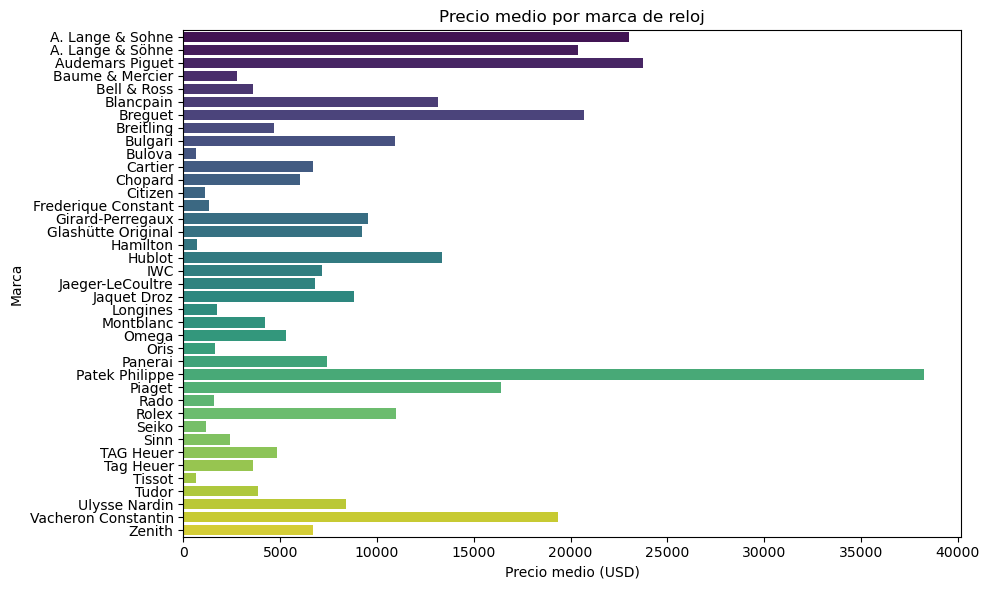

In [17]:
plt.figure(figsize=(10,6))
sns.barplot(x=precio_marca.values, y=precio_marca.index, hue=None, palette="viridis", legend=False)
plt.title("Precio medio por marca de reloj")
plt.xlabel("Precio medio (USD)")
plt.ylabel("Marca")
plt.tight_layout()
plt.show()

Aquí se construye un gráfico de barras horizontales que muestra el precio medio de los relojes agrupados por marca. Esta visualización facilita una comparación clara entre las diferentes marcas del dataset, permitiendo identificar cuáles están más asociadas al segmento de lujo.

Se utiliza `seaborn.barplot()` con una paleta de colores adecuada y se agregan etiquetas, ejes y títulos correctamente para garantizar que el gráfico sea legible, autoexplicativo y visualmente atractivo.

En este apartado realizaremos una excepción, y re-analizaremos lo mismo pero enfocándonos en un límite de precio (10.000$) que explicaremos más adelante.

## 5.1 Precio medio por marca. (Marcas 'Accesibles')

C:\Users\alexi\AppData\Local\Temp\ipykernel_21100\3315510111.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=marcas_accesibles.values, y=marcas_accesibles.index, hue=None, palette="crest", legend=False)


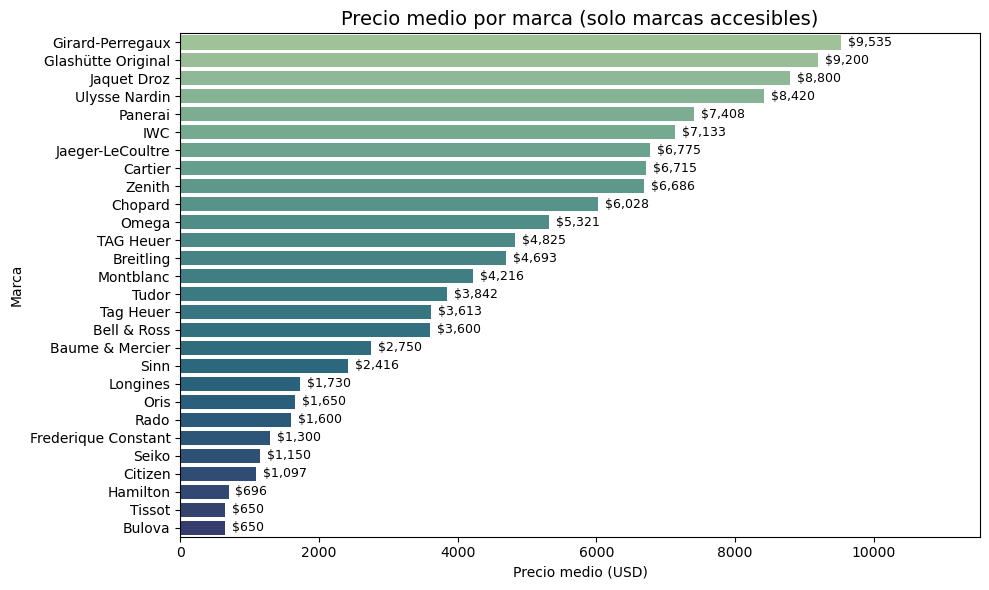

In [15]:
# Calcular precio medio por marca
precio_marca = df.groupby("Brand")["Price (USD)"].mean()

# Filtrar las consideradas accesibles
marcas_accesibles = precio_marca[precio_marca < 10000].sort_values(ascending=False)

# Visualización
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=marcas_accesibles.values, y=marcas_accesibles.index, hue=None, palette="crest", legend=False)

# Etiquetas del precio encima de cada barra
for i, valor in enumerate(marcas_accesibles.values):
    ax.text(valor + 100, i, f"${int(valor):,}", va='center', fontsize=9)

plt.title("Precio medio por marca (solo marcas accesibles)", fontsize=14)
plt.xlabel("Precio medio (USD)")
plt.ylabel("Marca")
plt.xlim(0, max(marcas_accesibles.values) + 2000)
plt.tight_layout()
plt.show()

## ¿Por qué analizar las marcas accesibles?

Si bien el mercado de relojes de lujo incluye modelos con precios muy elevados, la **gran mayoría de consumidores** interesados en adquirir un reloj de alta gama busca opciones dentro de un rango **relativamente asequible**. Por esta razón, tiene sentido centrarse en las marcas cuya media de precios se sitúa por debajo de los 10.000 USD.

Este tipo de análisis es útil porque:

- Representa mejor la **demanda real del mercado**, ya que las marcas con precios más moderados reciben mucha más atención por parte del público general.
- Ayuda a identificar **opciones competitivas** para consumidores que desean invertir en un reloj de lujo sin llegar a las cifras propias de marcas de alta relojería exclusiva.
- Permite a empresas del sector, distribuidores y analistas **comprender qué marcas dominan el segmento medio** y cómo se posicionan en relación con el precio.

Al visualizar únicamente las marcas accesibles, se evita que los precios extremadamente altos de algunas marcas distorsionen la percepción general, y se obtiene una visión más ajustada a la realidad de la mayoría de compradores potenciales.


## 6. Visualización II: Diagrama de dispersión Precio vs Diámetro

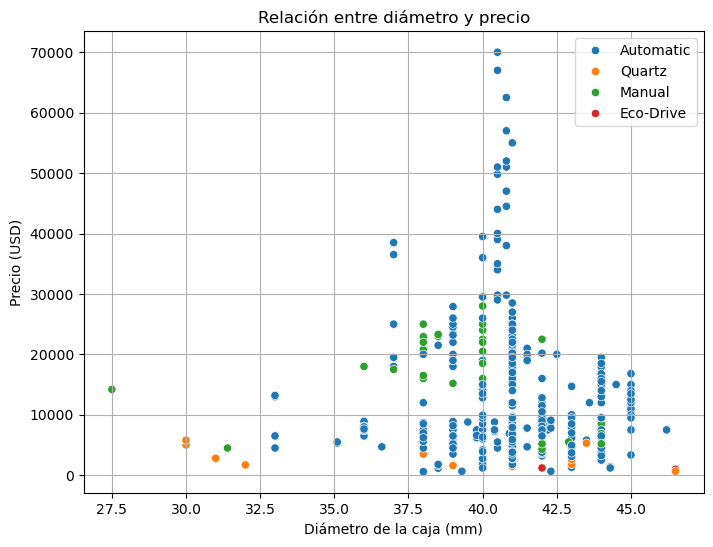

In [5]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Case Diameter (mm)", y="Price (USD)", hue="Movement Type")
plt.title("Relación entre diámetro y precio")
plt.xlabel("Diámetro de la caja (mm)")
plt.ylabel("Precio (USD)")
plt.legend()
plt.grid(True)
plt.show()

En este apartado se representa un **diagrama de dispersión** (`scatterplot`) entre el diámetro de la caja y el precio del reloj, diferenciando los puntos según el tipo de movimiento.

El objetivo es explorar si existe alguna correlación entre el tamaño del reloj y su precio, así como observar si ciertos tipos de movimiento se agrupan en rangos de precios o tamaños específicos.

Como se puede observar, la gran mayoría de modelos se concentran en un rango de diámetros que va desde los **37.5 mm hasta los 45 mm**, siendo especialmente destacable la elevada presencia de relojes —muchos de ellos de **alto valor económico**— en torno a los **40 mm y 41 mm**.

Este dato sugiere que los relojes con un diámetro de aproximadamente 40 mm representan una **preferencia estándar del mercado**, posiblemente por su equilibrio entre presencia visual, comodidad y versatilidad. Por tanto, se puede considerar que esta dimensión actúa como un **tamaño óptimo o dominante** dentro del sector de los relojes de lujo.

## 7. Detección de outliers

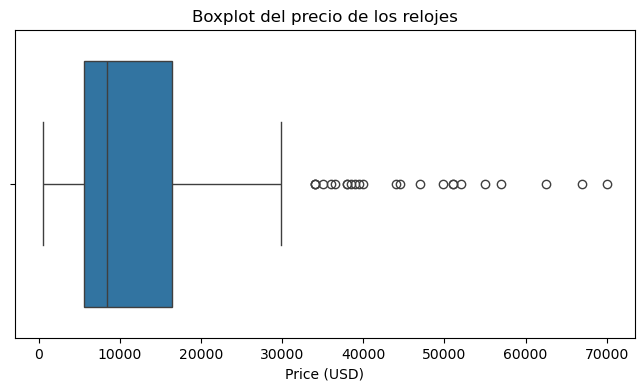

In [6]:
# Diagrama de caja para detectar relojes atípicos por precio
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Price (USD)"])
plt.title("Boxplot del precio de los relojes")
plt.show()



## Análisis de outliers en los precios

El análisis de outliers es fundamental en cualquier estudio estadístico, ya que permite identificar valores extremos que podrían distorsionar los resultados o revelar información interesante.

En este caso, se ha utilizado un **diagrama de caja (boxplot)** para examinar la distribución de precios de los relojes. El gráfico muestra una mayoría de modelos agrupados por debajo de los 15.000 USD, pero también revela la existencia de **relojes con precios significativamente más altos** (algunos por encima de los 30.000 USD o más), lo que sugiere la presencia de marcas de alta relojería como **Patek Philippe, Audemars Piguet o A. Lange & Söhne**.

Estos valores atípicos son esperables en un dataset de relojes de lujo, donde existe una gran dispersión de precios según el prestigio de la marca, los materiales empleados y la complejidad mecánica del modelo.

### ¿Qué hacer con los outliers?

- **Para análisis generales**, pueden conservarse si se desea tener una visión completa del mercado, incluyendo relojes exclusivos.
- **Para comparaciones de marcas accesibles**, conviene **filtrarlos temporalmente** para evitar que distorsionen la media o el rango visualizado.

La decisión dependerá del enfoque del análisis, pero su detección ya aporta valor: muestra la amplitud del mercado y las diferencias claras entre gamas de producto.


## 8. Visualización III: materiales y precio

C:\Users\alexi\AppData\Local\Temp\ipykernel_21100\1503960606.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


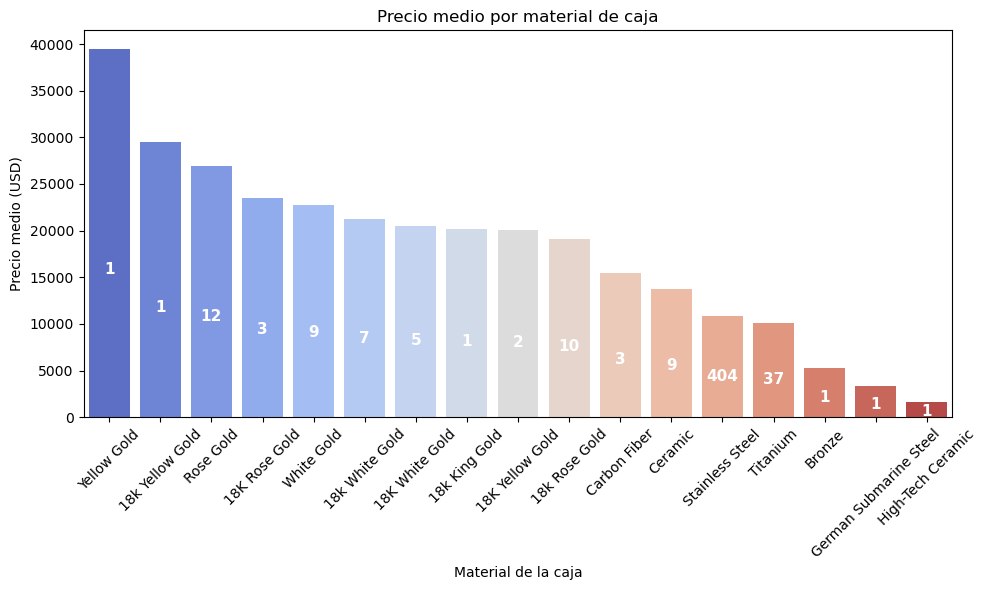

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Contar cantidad de relojes por material de caja
material_counts = df["Case Material"].value_counts()

# Calcular precio medio por material de caja
precio_material = df.groupby("Case Material")["Price (USD)"].mean()

# Unir ambas en un DataFrame
material_stats = pd.DataFrame({
    "Cantidad": material_counts,
    "Precio medio (USD)": precio_material
}).sort_values("Precio medio (USD)", ascending=False)

# Gráfico de barras
plt.figure(figsize=(10,6))
ax = sns.barplot(
    x=material_stats.index,
    y="Precio medio (USD)",
    data=material_stats,
    palette="coolwarm"
)

# Añadir etiquetas dentro de las barras (cantidad)
for i, (cantidad, precio) in enumerate(zip(material_stats["Cantidad"], material_stats["Precio medio (USD)"])):
    ax.text(i, precio * 0.4, f"{cantidad}", color="white", ha='center', va='center', fontsize=11, fontweight='bold')


plt.title("Precio medio por material de caja")
plt.xlabel("Material de la caja")
plt.ylabel("Precio medio (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Uno de los factores más determinantes en el precio de un reloj es el material de la caja, ya que influye tanto en el coste de fabricación como en la percepción de lujo y durabilidad.

A través del gráfico de barras construido, se puede observar que materiales como **oro rosa**, **platino** o **oro blanco** presentan los precios medios más altos, lo cual es coherente con su valor intrínseco como metales preciosos y su uso en piezas de alta relojería. Por otro lado, materiales como **acero inoxidable**, **cerámica** o **titanio** son mucho más comunes en modelos de gama media o accesible, con precios significativamente más bajos.



Además, al representar dentro de cada barra la cantidad de relojes por material, se aprecia que:

- El **acero inoxidable domina claramente en cantidad**, lo que lo convierte en el material más utilizado, probablemente por su buena relación calidad-precio y resistencia.
- Los materiales de lujo, aunque tienen precios altos, **aparecen en menor cantidad**, lo que refleja su exclusividad y producción limitada.

Este análisis ayuda a entender cómo el tipo de material actúa como indicador de segmentación de mercado, diferenciando modelos de entrada, gama media y alta gama en el universo de los relojes de lujo.

## 9. Análisis IV. Reloj más común en el mercado de los relojes de lujo

A partir del análisis exploratorio del conjunto de datos, es posible identificar el **reloj “típico”** o más representativo del mercado, lo que proporciona una base sólida para definir las características de un nuevo modelo competitivo.

### 9.1. Tipo de movimiento : Automático

La gran mayoría de modelos del dataset emplean movimiento **automático**, lo cual concuerda con la tendencia del mercado de lujo de priorizar mecanismos tradicionales y de calidad frente a opciones como el cuarzo o híbridos. Este tipo de movimiento es altamente valorado por los coleccionistas y transmite una imagen de sofisticación mecánica.

---

### 9.2. Material de la caja : Acero inoxidable

El **acero inoxidable** es, con diferencia, el material más utilizado. Su combinación de resistencia, coste contenido y estética elegante lo convierte en una elección preferida tanto para relojes deportivos como de vestir. Aunque materiales como el oro o el titanio aparecen en el dataset, lo hacen en menor cantidad y están asociados a segmentos premium.

---

### 9.3. Dimensiones : 40 mm

Los diámetros más frecuentes se sitúan entre **40 y 41 mm**, lo que indica una clara preferencia del mercado por este tamaño. Ofrece un equilibrio adecuado entre presencia visual y comodidad, siendo apto para la mayoría de muñecas.

---

### 9.4. Precio orientativo : 6.000 USD (aprox)

El análisis por marca y material sugiere que los relojes con las características anteriores suelen ubicarse en un rango de **precio entre 4.000 y 7.000 USD**. Este segmento es altamente competitivo, accesible dentro del lujo, y permite posicionar el producto sin entrar en el terreno de la alta relojería exclusiva.

---

### 9.5. Otras características comunes

- **Cristal:** Zafiro (duradero y presente en casi todos los modelos del dataset).
- **Complicaciones:** Función de fecha simple (la más habitual en modelos automáticos).
- **Correa:** Acero o cuero (ambas opciones tienen fuerte presencia).

---

## 10. Conclusiones

### Conclusiones sobre el uso de librerías de análisis y visualización

Este trabajo ha permitido poner en práctica diversas herramientas del ecosistema científico de Python:

- **Pandas** ha sido esencial para la carga, exploración, limpieza y manipulación del dataset. Sus funciones de agrupación, filtrado y transformación han facilitado una exploración estructurada de los datos.
- **NumPy** ha servido como soporte en tareas específicas de tratamiento numérico, como la extracción de valores y normalización de variables.
- **Seaborn** ha resultado especialmente útil para generar visualizaciones claras y estéticamente cuidadas, como gráficos de barras, dispersión, boxplots o radar. Su integración con `pandas` ha permitido una sintaxis fluida y potente.
- **Matplotlib** ha complementado la personalización y fine-tuning de las visualizaciones, añadiendo etiquetas, estilos y control total sobre la representación gráfica.

En conjunto, estas librerías han demostrado su capacidad para generar insights valiosos a partir de datos reales de forma ágil, flexible y reproducible. El trabajo evidencia que, con conocimientos básicos de Python y estas herramientas, es posible llevar a cabo un análisis exploratorio completo y profesional.

---

### Conclusiones específicas del análisis del mercado de relojes

A partir del análisis realizado sobre el dataset de relojes de lujo, pueden extraerse las siguientes conclusiones relevantes:

- **Precio y materiales:** Se observa una diferencia de precio clara entre los materiales de la caja. Los modelos fabricados con oro, platino o cerámica presentan precios medios significativamente más altos que aquellos hechos en acero inoxidable o titanio.
  
- **Relación tamaño/precio:** El diámetro de la caja, aunque no determina de forma directa el precio, muestra cierta relación en los modelos automáticos. La mayoría de relojes se concentran entre los **40 y 41 mm**, sugiriendo una preferencia estándar en diseño.

- **Outliers y segmentación:** Se identifican modelos con precios notablemente superiores al promedio, asociados principalmente a marcas exclusivas como Patek Philippe o Audemars Piguet. Estos valores, considerados **outliers**, reflejan la existencia de una **segmentación clara** dentro del mercado del lujo.

- **Perfil común del producto:** El análisis sugiere que un reloj de lujo típico combina: caja de acero inoxidable, cristal de zafiro, función de fecha, movimiento automático, diámetro de 40 mm y un precio estimado entre **5.000 y 7.000 USD**.

---

Estas conclusiones no solo permiten entender mejor el panorama actual del mercado de relojes, sino que además ofrecen una base sólida para la toma de decisiones estratégicas, como el **diseño de un nuevo producto** o el **reposicionamiento de marca en un segmento específico**.


Espero que esta lectura haya resultado interesante y enriquecedora, no solo por el tratamiento técnico del conjunto de datos, sino también por el acercamiento a un mundo tan apasionante y sofisticado como es el de los **relojes de lujo**.

Ha sido una oportunidad para combinar análisis de datos con una temática de alto valor cultural y comercial, explorando desde un enfoque cuantitativo las características que definen a estos objetos de precisión y diseño.

¡Gracias por acompañarme en este recorrido y un cordial saludo!